# Colab GPU End-to-End Training Notebook

This notebook is designed to run effortlessly on Google Colab with GPU (including via the Colab VS Code extension). Follow the sections step by step and ensure your runtime type is set to **GPU**.

- In Colab: Runtime → Change runtime type → Hardware accelerator: **GPU**
- Then run each cell from top to bottom.

## Step 1: GPU and (optional) Google Drive setup

This step prepares the environment:

- **On Colab:** we mount Google Drive so that models and results are saved under `MyDrive`.
- **On your own machine:** the code automatically skips the Colab‑specific part and only prints basic GPU information.

You do not need to change anything here. Just run the next code cell and check the printed messages.

In [17]:
# 1. Mount Google Drive and Verify GPU Availability
try:
    # This import only works on Google Colab
    from google.colab import drive  # type: ignore
    import subprocess
    IN_COLAB = True
except ImportError:
    drive = None
    import subprocess
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=False)
    print("Mounted Google Drive at /content/drive")
else:
    print("Running outside Google Colab – skipping drive.mount().")

print("\n=== GPU Info (nvidia-smi, if available) ===")
try:
    subprocess.run(["nvidia-smi"])
except FileNotFoundError:
    print("nvidia-smi not found; likely no NVIDIA GPU or drivers on this machine.")

Running outside Google Colab – skipping drive.mount().

=== GPU Info (nvidia-smi, if available) ===


## Step 2: Install and import ML libraries

This cell:

- Installs PyTorch, NumPy, pandas, matplotlib and scikit‑learn (on Colab or fresh environments).
- Imports everything needed for training.

If you already created the project environment with `requirements.txt`, these packages are already installed; running this cell is still safe, it simply ensures Colab is ready.

In [18]:
# 2. Install and Import ML Dependencies
!pip -q install torch torchvision torchaudio numpy pandas matplotlib scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

print("Torch version:", torch.__version__)

Torch version: 2.11.0+cpu


## Step 3: Select GPU or CPU automatically

This cell chooses the best available device:

- Uses the GPU (`cuda`) when available.
- Falls back to CPU when no GPU is present.

You can run the whole notebook on CPU; it will just be a bit slower. No manual configuration is required.

In [19]:
# 3. Set Up GPU-Aware Device Configuration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print(torch.cuda.get_device_name(0))
    print("Memory Allocated:", round(torch.cuda.memory_allocated(0)/1024**3, 2), "GB")
    print("Memory Cached:", round(torch.cuda.memory_reserved(0)/1024**3, 2), "GB")

Using device: cpu


## Step 4: Load and prepare the dataset

Here we:

- Load the **breast cancer** dataset from scikit‑learn.
- Split it into train / validation / test sets.
- Standardize the numeric features.
- Convert everything into PyTorch tensors and `DataLoader`s.

After running this cell you will see dataset shapes and how many training batches there are.

In [20]:
# 4. Load Dataset from Remote Source (Breast Cancer) and Prepare Splits

# We use a classic tabular dataset from scikit-learn for simplicity.
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

sk_data = load_breast_cancer()
X = sk_data.data
y = sk_data.target

print("Dataset shape:", X.shape)
print("Classes:", sk_data.target_names)

# Train/validation/test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("Train batches:", len(train_loader))

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Train batches: 7


## Step 5: Define the neural network model

This cell builds a small **MLP classifier**:

- Two hidden layers with ReLU activations and dropout.
- Final layer with 2 outputs (benign vs malignant).

You do not need to change the architecture to follow the notebook, but you can experiment with hidden size, dropout or learning rate later.

In [21]:
# 5. Build a Simple Neural Network Model

class BreastCancerMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
model = BreastCancerMLP(input_dim=input_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

BreastCancerMLP(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=2, bias=True)
  )
)


## Step 6: Train and monitor the model

This loop trains the network for several epochs and prints:

- Training loss
- Validation loss
- Validation accuracy

At the end, you will see two plots:

- **Loss curves** (train vs validation)
- **Validation accuracy over epochs**

Use these to check for underfitting (both losses high) or overfitting (train loss much lower than validation loss).

Epoch 01 | Train Loss: 0.6537 | Val Loss: 0.5820 | Val Acc: 0.9529
Epoch 02 | Train Loss: 0.5398 | Val Loss: 0.4765 | Val Acc: 0.9412
Epoch 03 | Train Loss: 0.4222 | Val Loss: 0.3631 | Val Acc: 0.9412
Epoch 04 | Train Loss: 0.3128 | Val Loss: 0.2594 | Val Acc: 0.9412
Epoch 05 | Train Loss: 0.2324 | Val Loss: 0.1824 | Val Acc: 0.9647
Epoch 06 | Train Loss: 0.1784 | Val Loss: 0.1327 | Val Acc: 0.9647
Epoch 07 | Train Loss: 0.1354 | Val Loss: 0.1021 | Val Acc: 0.9647
Epoch 08 | Train Loss: 0.1128 | Val Loss: 0.0810 | Val Acc: 0.9882
Epoch 09 | Train Loss: 0.0896 | Val Loss: 0.0697 | Val Acc: 0.9882
Epoch 10 | Train Loss: 0.0890 | Val Loss: 0.0624 | Val Acc: 0.9882
Epoch 11 | Train Loss: 0.0784 | Val Loss: 0.0576 | Val Acc: 0.9882
Epoch 12 | Train Loss: 0.0784 | Val Loss: 0.0544 | Val Acc: 0.9882
Epoch 13 | Train Loss: 0.0772 | Val Loss: 0.0527 | Val Acc: 0.9882
Epoch 14 | Train Loss: 0.0644 | Val Loss: 0.0507 | Val Acc: 0.9765
Epoch 15 | Train Loss: 0.0641 | Val Loss: 0.0502 | Val Acc: 0.

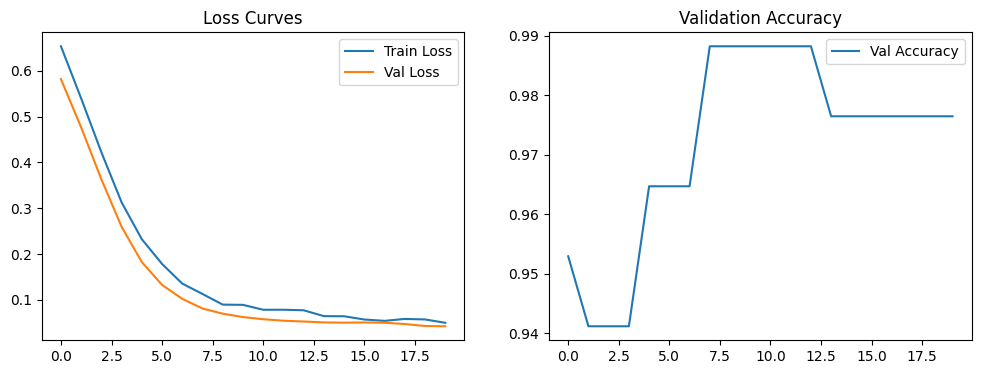

In [22]:
# 6. Train the Model on GPU and Track Metrics

num_epochs = 20
train_losses, val_losses, val_accuracies = [], [], []

for epoch in range(1, num_epochs + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_running_loss = 0.0
    correct, total = 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_running_loss += loss.item() * xb.size(0)

            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    epoch_val_acc = correct / total

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)

    print(f"Epoch {epoch:02d} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")

# Plot metrics
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.title('Loss Curves')

plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Val Accuracy')
plt.legend()
plt.title('Validation Accuracy')
plt.show()

## Step 7: Evaluate on the test set and save the model

Finally, this step:

- Computes **test accuracy** to estimate real‑world performance.
- Saves the trained model weights and scaler statistics.
- On Colab, these files go under `/content/drive/MyDrive/colab-ml-gpu-demo/`.
- On a local machine, they are stored under a `content` folder at the root of your main drive.

After running it, read the printed test accuracy and note where the files were saved.

## Step 8: Detailed evaluation (confusion matrix & report)

In this final analysis step we:

- Compute a **confusion matrix** on the test set.
- Show a **classification report** (precision, recall, F1) for each class.

This helps you understand *which* class the model confuses more, not just the overall accuracy.

In [23]:
# 7. Evaluate on Test Set, Save Checkpoints, and Export Final Model to Drive

from pathlib import Path

# Test evaluation
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")

# Save model and scaler locally in Colab (in Drive for persistence)
output_dir = Path('/content/drive/MyDrive/colab-ml-gpu-demo')
output_dir.mkdir(parents=True, exist_ok=True)

model_path = output_dir / 'breast_cancer_mlp.pt'
scaler_path = output_dir / 'scaler_params.npz'

# Move model to CPU before saving (for portability)
model_cpu = model.to('cpu')
state_dict = model_cpu.state_dict()
torch.save(state_dict, model_path)

# Save scaler statistics for later reuse
np.savez(
    scaler_path,
    mean=scaler.mean_,
    scale=scaler.scale_,
)

print(f"Saved model to {model_path}")
print(f"Saved scaler parameters to {scaler_path}")

print("\nYou can now download these files from Google Drive or reuse them in other notebooks or applications.")

Test Accuracy: 0.9651
Saved model to \content\drive\MyDrive\colab-ml-gpu-demo\breast_cancer_mlp.pt
Saved scaler parameters to \content\drive\MyDrive\colab-ml-gpu-demo\scaler_params.npz

You can now download these files from Google Drive or reuse them in other notebooks or applications.


In [ ]:
# 8. Detailed evaluation: confusion matrix and classification report
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Collect predictions and labels on the test set
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = yb.numpy()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds = np.concatenate(all_preds)
all_labels = np.concatenate(all_labels)

cm = confusion_matrix(all_labels, all_preds)
print("Confusion matrix (rows = true, cols = predicted):")
print(cm)

print("\nClassification report:")
print(classification_report(all_labels, all_preds, target_names=sk_data.target_names))

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.colorbar()
plt.xticks([0,1], sk_data.target_names, rotation=45)
plt.yticks([0,1], sk_data.target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
plt.tight_layout()
plt.show()